In [1]:
import os
import glob
import pandas as pd

def extract_distances_from_folders(base_path, stages):
    """
    Extracts distances (E1-PPE, E2-PPE, and E1-E2) from CSV files across multiple folders for different stages.

    Parameters:
        base_path (str): The base path where the stage folders are located.
        stages (list): A list of folder names (stages) to process (e.g., ['Nc12', 'Nc13']).

    Returns:
        dict: A dictionary containing DataFrames for each distance type ('3'-PPE', '5'-PPE', '3'-5') 
              for each stage.
    """
    result = {}

    for stage in stages:
        # Define the path to the folder containing the CSV files
        folder_path = os.path.join(base_path, stage)

        # Collect and concatenate only CSV files directly in the folder (no subdirectories)
        csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
        li = []
        for f in csv_files:
            df = pd.read_csv(f)
            li.append(df)

        # Check if there are any CSV files
        if not li:
            print(f"No CSV files found in {folder_path} for stage: {stage}")
            continue

        # Concatenate all DataFrames in the list
        stage_distances = pd.concat(li, axis=0, ignore_index=True)

        # Extract rows where only 'leftDist' is present. Drop NA for subset in leftDist column only. Here, leftDist correspond to E2-PPE distance.
        # This is dependent on which fluorophore you chose to be in the Left box in the find_spots GUI. In this case, 488, which is E2 was chosen 
        # to be on the Left. Henceforth, leftDist is E2-PPE distance. 
        left_dist = stage_distances.dropna(subset=['leftDist'])[
            ['Xleft', 'Yleft', 'Zleft', 'Xmiddle', 'Ymiddle', 'Zmiddle',
             'Xright', 'Yright', 'Zright', 'leftDist']
        ].rename(columns={'leftDist': "E2-PPE distance (um)"})

        # Extract rows where only 'rightDist' is present. Drop NA for subset in rightDist column only. This correspond to E1-PPE distance. 
        right_dist = stage_distances.dropna(subset=['rightDist'])[
            ['Xleft', 'Yleft', 'Zleft', 'Xmiddle', 'Ymiddle', 'Zmiddle',
             'Xright', 'Yright', 'Zright', 'rightDist']
        ].rename(columns={'rightDist': "E1-PPE distance (um)"})

        # Extract rows where only 'leftRightDist' is present. Drop NA for subset in leftRightDist column only. This correspond to E1-E2 distance. 
        left_right_dist = stage_distances.dropna(subset=['leftRightDist'])[
            ['Xleft', 'Yleft', 'Zleft', 'Xmiddle', 'Ymiddle', 'Zmiddle',
             'Xright', 'Yright', 'Zright', 'leftRightDist']
        ].rename(columns={'leftRightDist': "E1-E2 distance (um)"})

        # Store the DataFrames in the result dictionary
        result[f'{stage}_E2-PPE'] = left_dist
        result[f'{stage}_E1-PPE'] = right_dist
        result[f'{stage}_E1-E2'] = left_right_dist

    return result

In [2]:
# Loading 14C twist and no twist data 
base_path = '../../../../09_29_25_YW_twi/'
stages = ['twi', 'no_twi']

distance_data = extract_distances_from_folders(base_path, stages)

# Accessing the results for Nc14 late twist 
YW_E2_PPE_twist = distance_data['twi_E2-PPE']
YW_E1_PPE_twist = distance_data['twi_E1-PPE']
YW_E1_E2_twist = distance_data['twi_E1-E2']

# Accessing the results for Nc14 late twist 
YW_E2_PPE_no_twist = distance_data['no_twi_E2-PPE']
YW_E1_PPE_no_twist = distance_data['no_twi_E1-PPE']
YW_E1_E2_no_twist = distance_data['no_twi_E1-E2']


# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

def below_resolution_limit(p1, p2, res_sq):
    """
    Return True if the ellipsoidal distance between p1 and p2 is below the resolution limit.
    """
    try:
        return (
            ((p1[0] - p2[0]) ** 2) / res_sq[0] +
            ((p1[1] - p2[1]) ** 2) / res_sq[1] +
            ((p1[2] - p2[2]) ** 2) / res_sq[2]
        ) < 1.0
    except:
        return False  # if any coordinates are missing (NaN), skip comparison

# Apply resolution filtering
for key, df in distance_data.items():
    if "E2-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E2-PPE distance (um)"] = 0.0

    elif "E1-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xright", "Yright", "Zright", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xright"], row["Yright"], row["Zright"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-PPE distance (um)"] = 0.0

    elif "E1-E2" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xright", "Yright", "Zright"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xright"], row["Yright"], row["Zright"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-E2 distance (um)"] = 0.0

In [3]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Legend, LegendItem, HoverTool, Range1d
from bokeh.io import output_notebook
import numpy as np
from scipy.stats import gaussian_kde, ks_2samp

output_notebook()  # inline display in Jupyter

def generate_pdf_comparison_mutant(
    sample1_dataframe, sample2_dataframe,
    distance_column, title_prefix,
    sample1_name, sample1_color,
    sample2_name, sample2_color,
    n_bootstraps=1000
):
    """
    Generate a PDF comparison plot for 2 samples with KDE + 95% CI shading (bootstrapped),
    legend entries that include sample sizes and medians, and a KS test p-value printed to stdout.
    """

    # ---------- helpers ----------
    def preprocess_data(series):
        """Drop NaNs and add small jitter if there are very few unique values."""
        data = series.dropna().to_numpy()
        if data.size == 0:
            raise ValueError(f"No data after dropping NaNs in column '{distance_column}'.")
        if np.unique(data).size < 5:
            data = data + np.random.normal(0, 1e-3, size=data.shape)  # small noise
        return data

    def kde_and_bootstrap_ci(data, x_vals, n_boot=1000):
        """Compute KDE and 95% CI via bootstrapping over the KDE."""
        base_kde = gaussian_kde(data)
        y = base_kde(x_vals)

        boot = np.empty((n_boot, x_vals.size), dtype=float)
        n = len(data)
        for b in range(n_boot):
            bs = np.random.choice(data, size=n, replace=True)
            boot[b] = gaussian_kde(bs)(x_vals)

        ci_lower = np.percentile(boot, 2.5, axis=0)
        ci_upper = np.percentile(boot, 97.5, axis=0)
        return y, ci_lower, ci_upper

    def add_series(pdf_plot, x_vals, y_vals, ci_lower, ci_upper,
                   name, color, n_points, median_val, decimals=3):
        """Add line, CI area, and a legend item with (n=..., median=...)."""
        source = ColumnDataSource(data=dict(x=x_vals, y=y_vals,
                                            ci_lower=ci_lower, ci_upper=ci_upper))
        line = pdf_plot.line('x', 'y', source=source, line_width=3, color=color, name=name)
        area = pdf_plot.varea(x='x', y1='ci_lower', y2='ci_upper',
                              source=source, fill_alpha=0.25, fill_color=color)
        med_str = f"{median_val:.{decimals}f}"
        legend_item = LegendItem(label=f"{name} (n={n_points:,}, median={med_str})",
                                 renderers=[line, area])
        return legend_item

    # ---------- data prep ----------
    s1 = preprocess_data(sample1_dataframe[distance_column])
    s2 = preprocess_data(sample2_dataframe[distance_column])

    # Common x-grid spanning both samples
    xmin = min(s1.min(), s2.min())
    xmax = max(s1.max(), s2.max())
    # Pad slightly for nicer tails
    pad = 0.02 * (xmax - xmin if xmax > xmin else 1.0)
    x_vals = np.linspace(xmin - pad, xmax + pad, 1200)

    # ---------- compute KDEs + bootstrap CIs ----------
    y1, ci1_lo, ci1_hi = kde_and_bootstrap_ci(s1, x_vals, n_bootstraps)
    y2, ci2_lo, ci2_hi = kde_and_bootstrap_ci(s2, x_vals, n_bootstraps)

    n1, n2 = len(s1), len(s2)
    med1, med2 = np.median(s1), np.median(s2)

    # Store results
    phenotypes = [
        {"label": "twi",    "name": sample1_name, "color": sample1_color,
         "data": s1, "y": y1, "ci_lo": ci1_lo, "ci_hi": ci1_hi},
        {"label": "no twi", "name": sample2_name, "color": sample2_color,
         "data": s2, "y": y2, "ci_lo": ci2_lo, "ci_hi": ci2_hi},
    ]

    pdf_peaks = {}
    kde_results = {}

    # ---------- figure ----------
    pdf_plot = figure(
        title=f"{title_prefix} - PDF of {distance_column}",
        x_axis_label=distance_column,
        y_axis_label="Probability Density",
        tools="pan,wheel_zoom,box_zoom,reset",
        height=500, width=1000
    )

    # styling
    pdf_plot.title.text_font_size = "13pt"
    pdf_plot.title.align = "center"
    pdf_plot.axis.axis_label_text_font_size = "25pt"
    pdf_plot.axis.axis_label_text_font_style = "bold"
    pdf_plot.axis.major_label_text_font_size = "18pt"
    pdf_plot.axis.major_label_text_font_style = "bold"
    pdf_plot.axis.axis_line_width = 2
    pdf_plot.axis.axis_line_color = "black"
    pdf_plot.axis.major_tick_line_width = 3
    pdf_plot.axis.major_tick_line_color = "black"
    pdf_plot.axis.minor_tick_line_width = 2
    pdf_plot.axis.minor_tick_line_color = "black"
    pdf_plot.title.standoff = 20
    pdf_plot.x_range = Range1d(start=-0.1, end=2)
    pdf_plot.y_range = Range1d(start=0, end=2.2)
    pdf_plot.xgrid.visible = False
    pdf_plot.ygrid.visible = False
    # (keep your existing figure + styling)
    pdf_plot.x_range = Range1d(start=-0.1, end=2)
    pdf_plot.y_range = Range1d(start=0, end=2.2)  # fixed max at 2.2
    pdf_plot.xgrid.visible = False
    pdf_plot.ygrid.visible = False


    legend_items = []
    hover_tools = []

    # ---------- add both phenotypes ----------
    for p in phenotypes:
        # Peak location
        peak_x = x_vals[np.argmax(p["y"])]
        pdf_peaks[f"PDF_{p['label'].replace(' ', '_')}"] = peak_x
        kde_results[p["label"]] = {"x": x_vals, "y": p["y"]}

        n_points = len(p["data"])
        median_val = float(np.median(p["data"]))
        med_str = f"{median_val:.3f}"

        source = ColumnDataSource(data=dict(
            x=x_vals, y=p["y"], ci_lower=p["ci_lo"], ci_upper=p["ci_hi"]
        ))

        line = pdf_plot.line('x', 'y', source=source, line_width=3, color=p["color"], name=p["name"])
        area = pdf_plot.varea(x='x', y1='ci_lower', y2='ci_upper', source=source, fill_alpha=0.25, fill_color=p["color"])

        legend_items.append(
            LegendItem(
                label=f"{p['name']} (n={n_points:,}, median={med_str})",
                renderers=[line, area]
            )
        )

        hover = HoverTool(
            renderers=[line],
            tooltips=[("x", "@x{0.000}"), ("density", "@y{0.000}"), ("CI", "(@ci_lower{0.000}, @ci_upper{0.000})")]
        )
        hover_tools.append(hover)

    # Add legend (outside, right) and hovers
    legend = Legend(items=legend_items, location="center")
    legend.label_text_font_size = "10pt"
    pdf_plot.add_layout(legend, 'right')
    pdf_plot.legend.click_policy = "hide"
    for h in hover_tools:
        pdf_plot.add_tools(h)

    # KS test
    ks_pval = ks_2samp(s1, s2).pvalue
    print(f"K-S Test ({sample1_name} vs {sample2_name}): {ks_pval:.10f}")

    show(pdf_plot)

    return pdf_peaks, kde_results

Loading BokehJS ...

## Overall comparison of D-V (twist vs no twist)

In [4]:
pdf_peaks_e1_ppe, kde_results_e1_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_PPE_twist,
    sample2_dataframe=YW_E1_PPE_no_twist,
    distance_column="E1-PPE distance (um)",
    title_prefix="14C YW twist vs no twist",
    sample1_name = "YW_E1_PPE_twist",
    sample1_color = "#505050",
    sample2_name = "YW_E1_PPE_no_twist",
    sample2_color = "#1E90FF"
)

K-S Test (YW_E1_PPE_twist vs YW_E1_PPE_no_twist): 0.0003238960


In [5]:
pdf_peaks_e1_ppe

{'PDF_twi': np.float64(0.30453130902595504),
 'PDF_no_twi': np.float64(0.30453130902595504)}

In [6]:
pdf_peaks_e2_ppe, kde_results_e2_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E2_PPE_twist,
    sample2_dataframe=YW_E2_PPE_no_twist,
    distance_column="E2-PPE distance (um)",
    title_prefix="14C YW twist vs no twist",
    sample1_name = "YW_E2_PPE_twist",
    sample1_color = "#505050",
    sample2_name = "YW_E2_PPE_no_twist",
    sample2_color = "#1E90FF"
)

K-S Test (YW_E2_PPE_twist vs YW_E2_PPE_no_twist): 0.0254671304


In [7]:
pdf_peaks_e2_ppe

{'PDF_twi': np.float64(0.5041617437345293),
 'PDF_no_twi': np.float64(0.3595954405353943)}

In [8]:
kde_results_e2_ppe

{'twi': {'x': array([-0.03968292, -0.03796189, -0.03624087, ...,  2.0203869 ,
          2.02210793,  2.02382895], shape=(1200,)),
  'y': array([0.31280132, 0.31471185, 0.31662486, ..., 0.18041257, 0.17949434,
         0.17857379], shape=(1200,))},
 'no twi': {'x': array([-0.03968292, -0.03796189, -0.03624087, ...,  2.0203869 ,
          2.02210793,  2.02382895], shape=(1200,)),
  'y': array([0.39283666, 0.39599635, 0.39916761, ..., 0.09180327, 0.09105822,
         0.09031365], shape=(1200,))}}

In [9]:
pdf_peaks_e1_e2, kde_results_e1_e2 = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_E2_twist,
    sample2_dataframe=YW_E1_E2_no_twist,
    distance_column="E1-E2 distance (um)",
    title_prefix="14C YW twist vs no twist",
    sample1_name = "YW_E1_E2_twist",
    sample1_color = "#505050",
    sample2_name = "YW_E1_E2_no_twist",
    sample2_color = "#1E90FF"
)

K-S Test (YW_E1_E2_twist vs YW_E1_E2_no_twist): 0.1119936198


## A vs P comparison for twist vs no twist region

In [10]:
# Loading 14C twist and no twist data 
base_path = '../../../../09_29_25_YW_twi/'
stages = ['twi_A', 'twi_C']

distance_data = extract_distances_from_folders(base_path, stages)

# Accessing the results for Nc14 late twist 
YW_E2_PPE_twist_A = distance_data['twi_A_E2-PPE']
YW_E1_PPE_twist_A = distance_data['twi_A_E1-PPE']
YW_E1_E2_twist_A = distance_data['twi_A_E1-E2']

# Accessing the results for Nc14 late twist 
YW_E2_PPE_twist_C = distance_data['twi_C_E2-PPE']
YW_E1_PPE_twist_C = distance_data['twi_C_E1-PPE']
YW_E1_E2_twist_C = distance_data['twi_C_E1-E2']


# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

def below_resolution_limit(p1, p2, res_sq):
    """
    Return True if the ellipsoidal distance between p1 and p2 is below the resolution limit.
    """
    try:
        return (
            ((p1[0] - p2[0]) ** 2) / res_sq[0] +
            ((p1[1] - p2[1]) ** 2) / res_sq[1] +
            ((p1[2] - p2[2]) ** 2) / res_sq[2]
        ) < 1.0
    except:
        return False  # if any coordinates are missing (NaN), skip comparison

# Apply resolution filtering
for key, df in distance_data.items():
    if "E2-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E2-PPE distance (um)"] = 0.0

    elif "E1-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xright", "Yright", "Zright", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xright"], row["Yright"], row["Zright"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-PPE distance (um)"] = 0.0

    elif "E1-E2" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xright", "Yright", "Zright"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xright"], row["Yright"], row["Zright"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-E2 distance (um)"] = 0.0

#### Twist region Anterior vs Posterior

In [29]:
pdf_peaks_e1_ppe, kde_results_e1_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_PPE_twist_A,
    sample2_dataframe=YW_E1_PPE_twist_C,
    distance_column="E1-PPE distance (um)",
    title_prefix="14C YW A vvs P in twist",
    sample1_name = "YW_E1_PPE_twist A",
    sample1_color = "#6B5F7A",
    sample2_name = "YW_E1_PPE_twist P",
    sample2_color = "#27AE60"
)

K-S Test (YW_E1_PPE_twist A vs YW_E1_PPE_twist P): 0.0182535151


In [13]:
# Loading 14C twist and no twist data 
base_path = '../../../../09_29_25_YW_twi/'
stages = ['no_twi_A', 'no_twi_C']

distance_data = extract_distances_from_folders(base_path, stages)

# Accessing the results for Nc14 late twist 
YW_E2_PPE_no_twist_A = distance_data['no_twi_A_E2-PPE']
YW_E1_PPE_no_twist_A = distance_data['no_twi_A_E1-PPE']
YW_E1_E2_no_twist_A = distance_data['no_twi_A_E1-E2']

# Accessing the results for Nc14 late twist 
YW_E2_PPE_no_twist_C = distance_data['no_twi_C_E2-PPE']
YW_E1_PPE_no_twist_C = distance_data['no_twi_C_E1-PPE']
YW_E1_E2_no_twist_C = distance_data['no_twi_C_E1-E2']


# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

# Define squared resolution limits (XY: 0.12 µm, Z: 0.35 µm)
res_squared = [0.12**2, 0.12**2, 0.35**2]

def below_resolution_limit(p1, p2, res_sq):
    """
    Return True if the ellipsoidal distance between p1 and p2 is below the resolution limit.
    """
    try:
        return (
            ((p1[0] - p2[0]) ** 2) / res_sq[0] +
            ((p1[1] - p2[1]) ** 2) / res_sq[1] +
            ((p1[2] - p2[2]) ** 2) / res_sq[2]
        ) < 1.0
    except:
        return False  # if any coordinates are missing (NaN), skip comparison

# Apply resolution filtering
for key, df in distance_data.items():
    if "E2-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E2-PPE distance (um)"] = 0.0

    elif "E1-PPE" in key:
        for idx, row in df.iterrows():
            if row[["Xright", "Yright", "Zright", "Xmiddle", "Ymiddle", "Zmiddle"]].notna().all():
                p1 = [row["Xright"], row["Yright"], row["Zright"]]
                p2 = [row["Xmiddle"], row["Ymiddle"], row["Zmiddle"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-PPE distance (um)"] = 0.0

    elif "E1-E2" in key:
        for idx, row in df.iterrows():
            if row[["Xleft", "Yleft", "Zleft", "Xright", "Yright", "Zright"]].notna().all():
                p1 = [row["Xleft"], row["Yleft"], row["Zleft"]]
                p2 = [row["Xright"], row["Yright"], row["Zright"]]
                if below_resolution_limit(p1, p2, res_squared):
                    df.at[idx, "E1-E2 distance (um)"] = 0.0

#### No twist region Anterior vs Posterior

In [14]:
pdf_peaks_e1_ppe, kde_results_e1_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_PPE_no_twist_A,
    sample2_dataframe=YW_E1_PPE_no_twist_C,
    distance_column="E1-PPE distance (um)",
    title_prefix="14C YW A vvs P in no twist",
    sample1_name = "YW_E1_PPE_no_twist A",
    sample1_color = "#6B5F7A",
    sample2_name = "YW_E1_PPE_no_twist P",
    sample2_color = "#27AE60"
)

K-S Test (YW_E1_PPE_no_twist A vs YW_E1_PPE_no_twist P): 0.1039652484


#### Twist vs no twist Anterior comparison

In [15]:
pdf_peaks_e1_ppe, kde_results_e1_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_PPE_twist_A,
    sample2_dataframe=YW_E1_PPE_no_twist_A,
    distance_column="E1-PPE distance (um)",
    title_prefix="14C twist vs no twist anterior",
    sample1_name = "YW_E1_PPE_twist_A",
    sample1_color = "#505050",
    sample2_name = "YW_E1_PPE_no_twist_A",
    sample2_color = "#1E90FF"
)

K-S Test (YW_E1_PPE_twist_A vs YW_E1_PPE_no_twist_A): 0.0313475275


#### Twist vs no Twist Posterior region

In [28]:
pdf_peaks_e1_ppe, kde_results_e1_ppe = generate_pdf_comparison_mutant(
    sample1_dataframe=YW_E1_PPE_twist_C,
    sample2_dataframe=YW_E1_PPE_no_twist_C,
    distance_column="E1-PPE distance (um)",
    title_prefix="14C twist vs no twist posterior",
    sample1_name = "YW_E1_PPE_twist_P",
    sample1_color = "#505050",
    sample2_name = "YW_E1_PPE_no_twist_P",
    sample2_color = "#1E90FF"
)

K-S Test (YW_E1_PPE_twist_P vs YW_E1_PPE_no_twist_P): 0.1903224061


# Contour triangle

In [19]:
def compute_triangle_vertices_from_PDF(d1_arr, d2_arr, p_d1_arr, p_d2_arr, d3):
    """
    Vectorized computation of triangle coordinates and joint PDF values.
    Here, we assumes that d1 and d2 are independent so the joint PDF is the product
    of individual d1 and d2. 
    
    Triangle Inequality Mask is also applied to make sure only valid triangles.  
    are kept.
    
    This generated a 2D scatter showing likely triangle configurations based on
    observed pairwise distances.
    """
    D1, D2 = np.meshgrid(d1_arr, d2_arr, indexing='ij')
    P1, P2 = np.meshgrid(p_d1_arr, p_d2_arr, indexing='ij')
    p = P1 * P2

    # Triangle inequality mask
    valid = (D1 + D2 >= d3) & (D1 + d3 >= D2) & (D2 + d3 >= D1)

    # Coordinates
    x_C = np.where(valid, (d3**2 + D2**2 - D1**2) / (2 * d3), np.nan)
    y_C = np.where(valid, np.sqrt(D2**2 - x_C**2), np.nan)

    return x_C, y_C, np.where(valid, p, np.nan)

def enhance_plot_axis(ax, font_size=18, line_width=3):
    """
    Enhances the plot axis by increasing font size, bolding text, and thickening lines.

    Parameters:
        ax (matplotlib.axes.Axes): The axis to modify.
        font_size (int): The size of the tick labels.
        line_width (int): The width of the axis lines.
    """
    # Set font size and bold text for axis labels and tick labels
    ax.xaxis.label.set_fontsize(font_size)
    ax.yaxis.label.set_fontsize(font_size)
    ax.xaxis.label.set_fontweight('bold')
    ax.yaxis.label.set_fontweight('bold')
    
    ax.tick_params(axis='both', which='major', labelsize=font_size, width=line_width)
    
    # Increase axis line thickness
    for spine in ax.spines.values():
        spine.set_linewidth(line_width)

In [20]:
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import NearestNDInterpolator
import numpy as np

def compute_weighted_Z(d1_arr, d2_arr, p_d1_arr, p_d2_arr,
                       d3_arr, p_d3_arr, xi, yi,
                       num_samples=50, subsample_stride=3,tail_frac=0.1, tail_boost=3, return_mode_d3=False):
    """
    Compute a weighted 2D PDF surface by integrating over triangle space
    using evenly spaced d3 values and normalized weights.

    Returns:
        Z_weighted: 2D array of weighted probability surface
        X_grid, Y_grid: coordinate grids
        mode_d3 (optional): d3 value whose PDF gives triangle closest to PDF peak
        
    First we created a 2D grid in which we evalulate triangle vertex coordinates. 
    In order to save time, we picks even spaced d3 to avoid bias. In order 
    to make sure everything is a valid PDF we normalizes the sum to 1. 
    
    Riemann sum approximation to get the weights of the d3 to ensure that contributions
    to final surface are proportional to the total probability density area under p_d3. 
    
    Second, we initializes an empty PDF grid which iterates over all sampled d3 values
    and their weights. For each fixed d3 we compute a triangle shapes from d1, d3 also. 
    This can give us a set of triangle coordinates (x_C, y_C) with a corresponding joint probability
    value (p_val) for each triangle. However, these triangle coordinates are irregularly
    spaced and is not evenly spaced on a rectangular grid. Hence, the interpolator (NearestNDInterpolator)
    takes the valid triangle positions and their probability, interpolates the values to 
    a smooth defined grid. Hence, each point on the grid get assigned a value from the
    nearest original data point in (x,y) triangle space. 
    
    After plotted, the interpolator is normalizes so the whole PDF surface sums to 1. 
    Then, PDF is multiplied by the weight (probability of d3). 
    This weighted contribution is added to the joint probability density. 
    Final normalization ensures the total surface d1,d2,d3 joint probability intergrates to 1 across all d3. 
    """
    # Create grid
    X_grid, Y_grid = np.meshgrid(xi, yi)

   # --- Evenly spaced d3 sampling ---
    indices_even = np.linspace(0, len(d3_arr) - 1, num_samples, dtype=int)
    d3_sampled = d3_arr[indices_even]
    p_d3_sampled = p_d3_arr[indices_even]
    p_d3_sampled /= np.sum(p_d3_sampled)  # normalize
    
    # Convert p_d3 to weights via numerical integration (Riemann sum)
    bin_edges = np.concatenate([
        [d3_sampled[0] - (d3_sampled[1] - d3_sampled[0]) / 2],
        (d3_sampled[:-1] + d3_sampled[1:]) / 2,
        [d3_sampled[-1] + (d3_sampled[-1] - d3_sampled[-2]) / 2]
    ])
    
    bin_widths = np.diff(bin_edges)
    weights = p_d3_sampled * bin_widths
    weights /= np.sum(weights)

    # --- Optional subsampling for performance ---
    d1_sub = d1_arr[::subsample_stride]
    p_d1_sub = p_d1_arr[::subsample_stride]
    d2_sub = d2_arr[::subsample_stride]
    p_d2_sub = p_d2_arr[::subsample_stride]

    Z_weighted = np.zeros_like(X_grid)
    total_weight = 0
    dx, dy = xi[1] - xi[0], yi[1] - yi[0]  # Grid resolution for area normalization
    #d3_sampled = [0.282108477293377]
    #d3_sampled = [0.6]
    #weights = [1] 
    for d3, w in zip(d3_sampled, weights):
        x_coords, y_coords, p_vals = compute_triangle_vertices_from_PDF(
            d1_sub, d2_sub, p_d1_sub, p_d2_sub, d3
        )

        valid = ~np.isnan(x_coords) & ~np.isnan(y_coords) & ~np.isnan(p_vals)
        if np.count_nonzero(valid) == 0:
            continue
            
        interpolator = NearestNDInterpolator(
            list(zip(x_coords[valid], y_coords[valid])), 
            p_vals[valid]
        )
        Z_interp = interpolator(X_grid, Y_grid)
        #print("Fraction of NaNs in Z_interp:", np.isnan(Z_interp).mean())
        #Z_interp = np.nan_to_num(Z_interp, nan=0.0)
        area = np.sum(Z_interp) * dx * dy
        if area > 0:
            Z_interp /= area  # Normalize each surface
            Z_weighted += Z_interp * w
            if return_mode_d3:
                Z_stack.append(Z_interp)
                d3_used.append(d3)
        total_weight += w
    if total_weight == 0:
        raise ValueError("Total weight is zero in compute_weighted_Z.")
    Z_weighted /= total_weight
    print (total_weight)
    print(f"Final normalized Z surface area: {np.sum(Z_weighted) * dx * dy:.5f}")
    
    return Z_weighted, X_grid, Y_grid

In [21]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap
from matplotlib.patches import Polygon
from matplotlib import cm
from matplotlib import colormaps
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import LinearNDInterpolator
from scipy.stats import rv_discrete
from scipy.interpolate import interpn
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D


def plot_contour_stage(d1_arr, d2_arr, p_d1_arr, p_d2_arr,
                       d3_arr, p_d3_arr, title,show_legend=True, x_tick_limit=None, num_samples=10, vmin=None, vmax=None):
    """
    Plots a normalized 2D PDF contour for a single condition (e.g., YW or PPE).

    Args:
        d1_arr, d2_arr: distance arrays
        p_d1_arr, p_d2_arr: PDF values along d1 and d2
        yw_mode: scalar distance for triangle construction
        mode_values: tuple of (d1, d2, d3) for triangle mode
        title: plot title
        vmin, vmax: color scale bounds
        xi, yi: grid coordinates
        
    This is the plotting function. First we define the actual grid for the contour.
    Then, using previous function we compute a 2D joint PDF over triangle vertex
    positions (from combination of d1,d2,d3) which result in a probability 
    density map of how the PPE (vertex C) is positioned in a triangle space. 
    
    Then, we locate the higest density PPE point and plot the green dot. 
    We place E1 (0,0) and E2 on the x-axis with the most probable E1-E2 distance. 
    Triangles were drawn. 
    Red dots projects sampled d3_array of distances for E1-E2 on the x-axis. 
    
    Contourf function creates a smoothed density heatmap of the PPE positions. 
    """
    # Create a regular grid to interpolate onto
    xi = np.linspace(-0.8, 2, 100)
    yi = np.linspace(-0, 1, 75)
    
    Z_weighted, X_grid, Y_grid = compute_weighted_Z(d1_arr, d2_arr, p_d1_arr, p_d2_arr,
                       d3_arr, p_d3_arr, xi, yi,
                       num_samples=50, subsample_stride=3
   )

    # --- PPE KDE peak ---
    peak_idx = np.unravel_index(np.argmax(Z_weighted), Z_weighted.shape)
    peak_x = X_grid[peak_idx]
    peak_y = Y_grid[peak_idx]
    ppe_xy = np.array([peak_x, peak_y])  # This will be your green dot

    # --- Most probable E1–E2 distance ---
    i_mode = np.argmax(p_d3_arr)
    d3_mode = d3_arr[i_mode]
    
    # Anchor E1 and E2 along the x-axis
    E1 = np.array([0.0, 0.0])
    E2 = np.array([d3_mode, 0.0])  # Red dot at d3_mode
    
   # Make sure to define ax before plotting
    fig, ax = plt.subplots(figsize=(20, 10), constrained_layout=False)

    #Define colormap
    white_purple_hot_orange = LinearSegmentedColormap.from_list(
        "white_purple_hot_orange",
        [
            (0.0, "white"),
            (0.15, "#D8BFD8"),   # lighter purple sooner
            (0.25, "purple"),    # narrower purple
            (0.55, "#FFD580"),   # expand soft orange
            (0.8, "#FF8C00"),    # strong orange
            (1.0, "#FF4500")     # fire orange
        ]
    )

    # --- Contour ---
    levels = np.linspace(vmin, vmax, 15) if (vmin is not None and vmax is not None) else 15
    contour = ax.contourf(X_grid, Y_grid, Z_weighted,
                          levels=levels, cmap=white_purple_hot_orange,
                          vmin=vmin, vmax=vmax)

    # Vertical contour colorbar (right side)
    cbar_contour = fig.colorbar(contour, ax=ax, orientation="vertical", pad=0.02)
    cbar_contour.set_label("KDE Density")

    
    # --- Hybrid triangle: PPE at KDE peak, E2 at d3 mode ---
    ax.plot([E1[0], E2[0]], [E1[1], E2[1]], color='black', linestyle='-', linewidth = 3)         # E1–E2 base
    ax.plot([E1[0], ppe_xy[0]], [E1[1], ppe_xy[1]], color='black', linestyle='-', linewidth = 3) # E1–PPE
    ax.plot([E2[0], ppe_xy[0]], [E2[1], ppe_xy[1]], color='black', linestyle='-', linewidth = 3) # E2–PPE

    # Plot the three dots
    ax.plot(*E1, 'o', color='blue', markersize=30, label='E1 (fixed)', zorder=5)
    ax.plot(*E2, 'o', color='red', markersize=30, label='E2 (d3 mode)', zorder=5)
    ax.plot(*ppe_xy, 'o', color='green', markersize=30, label='PPE (KDE peak)', zorder=6)


    # --- E1–E2 marginal strip + colorbar (outside the contour) ---

    # --- MAIN AX FORMATTING (keep axes visible) ---
    ax.set_xlim(-0.8, 1.2)
    ax.set_ylim(-0.08, 1.0)                 # small white band at bottom
    ax.set_aspect('equal', adjustable='box')
    ax.tick_params(axis='x', labelbottom=True, bottom=True)
    ax.tick_params(axis='y', labelleft=True, left=True)
    # after you plot the contour/triangle/dots, and BEFORE creating ax_line/cax:
    ax.set_xlabel("X (µm)", fontsize=16, labelpad=10)
    ax.set_ylabel("Y (µm)", fontsize=16, labelpad=10)
    
    # make sure the labels are visible on the main axis
    ax.tick_params(axis='x', labelbottom=True, bottom=True)
    ax.tick_params(axis='y', labelleft=True, left=True)

    # --- STRIP AXIS FOR THE LINE (do NOT sharex) ---
    divider = make_axes_locatable(ax)
    ax_line = divider.append_axes("bottom", size="8%", pad=0.9)   # thin strip just below square
    ax_line.set_xlim(ax.get_xlim())                              # match x-range, but don't sharex
    ax.set_title(title, fontsize=18, fontweight='bold', pad=12)
    
    # Build segments along E1–E2 (x only; y=0 in the strip)
    direction = E2 - E1
    direction = np.array([1.0, 0.0]) if np.allclose(direction, 0) else direction/np.linalg.norm(direction)
    x_line = (direction[None,:] * d3_arr[:,None])[:,0]
    pts = np.column_stack([x_line, np.zeros_like(x_line)]).reshape(-1,1,2)
    segments = np.concatenate([pts[:-1], pts[1:]], axis=1)

    # Colored line in the strip (NOT on 'ax')
    norm = plt.Normalize(0.0, 1.60)
    lc = LineCollection(segments, cmap='Greys', norm=norm)
    lc.set_array(p_d3_arr)
    lc.set_linewidth(12)
    ax_line.add_collection(lc)
    lc.set_clim(0.0, 1.60)

    # Clean the strip
    ax_line.set_ylim(-0.5, 0.5)
    ax_line.set_xticks([]); ax_line.set_yticks([])
    for s in ax_line.spines.values(): s.set_visible(False)
    
    # --- COLORBAR OUTSIDE (figure-level axis under the square) ---
    # make some bottom margin for the bar
    fig.subplots_adjust(bottom=0.22)   # tweak if your figure is taller/shorter
    
    # place the colorbar axis using the main axis position in figure coords
    pos = ax.get_position()            # Bbox in figure fraction coords
    gap, height = 0.06, 0.04           # gap below square, and bar thickness (tweak)
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - gap - height, pos.width, height])
    
    cb = fig.colorbar(lc, cax=cbar_ax, orientation="horizontal")
    cb.set_label("Probability Density (E1–E2)")
    
    enhance_plot_axis(ax, font_size=18, line_width=3)
    if show_legend:
        ax.legend(
            loc='center left',
            bbox_to_anchor=(1.25, 0.5),
            fontsize=14,
            title="Legend",
            markerscale=1,
            borderaxespad=1.2,
            labelspacing=1.2
        )
    # Grab the existing legend entries (E1, E2, PPE, etc.)
    plt.show()
    return Z_weighted, X_grid, Y_grid, E1, E2, ppe_xy

0.9822895530978469
Final normalized Z surface area: 1.00000


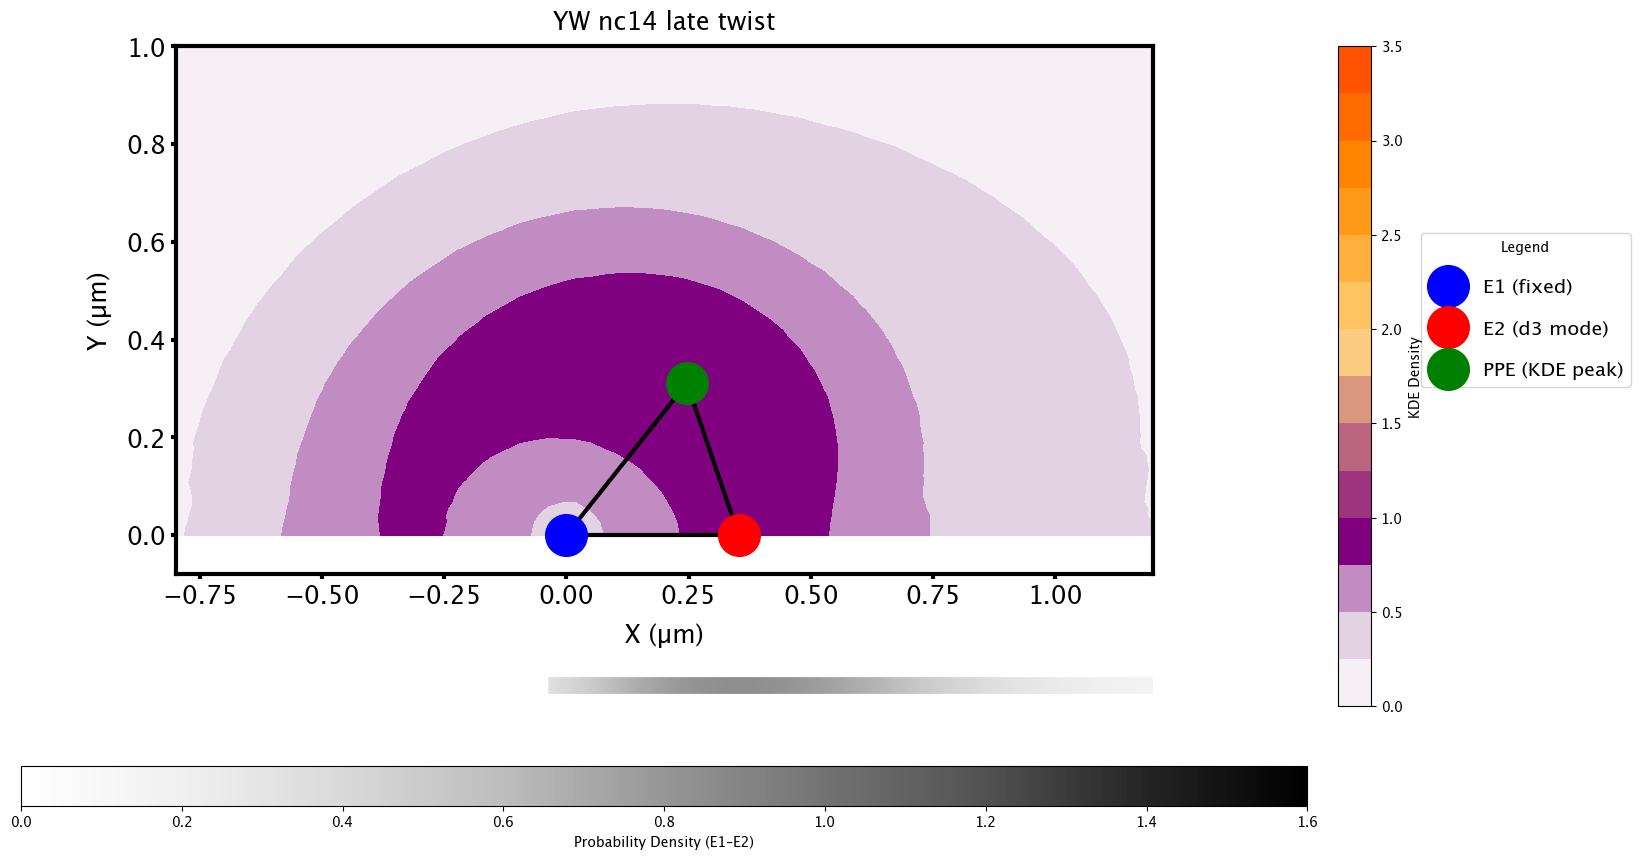

In [22]:
Z_weighted_nc14_late_twist, X_grid_nc14_late_twist, Y_grid_nc14_late_twist, E1_nc14_late_twist, E2_nc14_late_twist, PPE_nc14_late_twist = plot_contour_stage(kde_results_e2_ppe['twi']['x'], kde_results_e1_ppe['twi']['x'], 
                   kde_results_e2_ppe['twi']['y'], kde_results_e1_ppe['twi']['y'], 
                   kde_results_e1_e2['twi']['x'], kde_results_e1_e2['twi']['y'],
                   title="YW nc14 late twist", show_legend=True, x_tick_limit=None, num_samples=10, vmin=0, vmax=3.5)

0.9803032423965602
Final normalized Z surface area: 1.00000


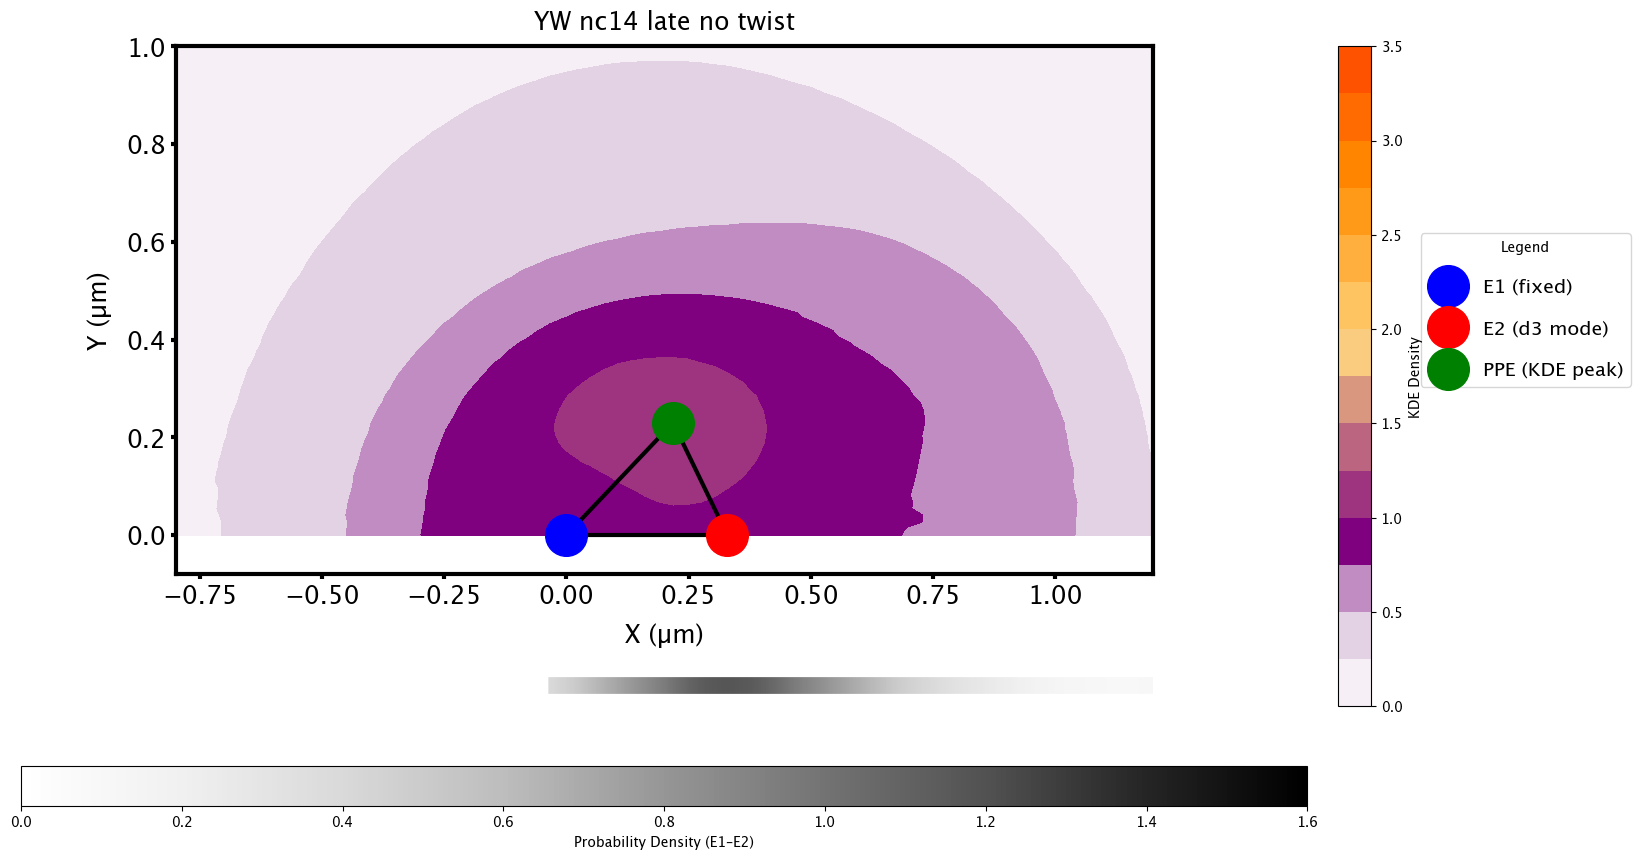

In [23]:
Z_weighted_nc14_late_no_twist, X_grid_nc14_late_no_twist, Y_grid_nc14_late_no_twist, E1_nc14_late_no_twist, E2_nc14_late_no_twist, PPE_nc14_late_no_twist = plot_contour_stage(kde_results_e2_ppe['no twi']['x'], kde_results_e1_ppe['no twi']['x'], 
                   kde_results_e2_ppe['no twi']['y'], kde_results_e1_ppe['no twi']['y'], 
                   kde_results_e1_e2['no twi']['x'], kde_results_e1_e2['no twi']['y'],
                   title="YW nc14 late no twist", show_legend=True, x_tick_limit=None, num_samples=10, vmin=0, vmax=3.5)

# Subtraction contour

In [24]:
# Re-import necessary libraries after kernel reset
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib import colormaps as cm

# ---------------- utilities ----------------
def _span_to_fig(ax, x_left, x_right):
    x0, x1 = ax.get_xlim()
    bbox   = ax.get_position()
    u0 = (x_left  - x0) / (x1 - x0)
    u1 = (x_right - x0) / (x1 - x0)
    left_u, right_u = (min(u0, u1), max(u0, u1))
    left_fig  = bbox.x0 + left_u  * bbox.width
    width_fig = (right_u - left_u) * bbox.width
    return left_fig, width_fig

def _draw_kde_strip_from_e1_positions(
    fig, ax_main, *,
    E1, E2, d, p,
    strip_bottom, strip_h,
    cb_bottom, cb_h,
    cmap, label, show_xlabel=False,
    unit_max=False,           # <— NEW: False = absolute scale
    pdf_vmin=0.0, pdf_vmax=1.6
):
    d = np.asarray(d, float); p = np.asarray(p, float)
    order = np.argsort(d); d, p = d[order], p[order]

    E1x, E2x = float(E1[0]), float(E2[0])
    xlim0, xlim1 = ax_main.get_xlim()
    sign = 1.0 if E2x >= E1x else -1.0

    d_cap = (xlim1 - E1x) if sign > 0 else (E1x - xlim0)
    d_cap = max(0.0, float(d_cap))
    if d_cap == 0:
        return None, None

    keep = (d >= 0) & (d <= d_cap)
    if not np.any(keep):
        d_vis = np.array([0.0, d_cap])
        p_vis = np.interp(d_vis, d, p, left=p[0] if d.size else 0, right=p[-1] if d.size else 0)
    else:
        d_vis = d[keep]; p_vis = p[keep]
        if d_vis[0] > 0:
            p0 = np.interp(0.0, d, p); d_vis = np.insert(d_vis, 0, 0.0); p_vis = np.insert(p_vis, 0, p0)
        if d_vis[-1] < d_cap:
            pE = np.interp(d_cap, d, p); d_vis = np.append(d_vis, d_cap); p_vis = np.append(p_vis, pE)

    # —— SCALE CHOICE ——
    if unit_max:
        vmin, vmax = 0.0, 1.0
        p_draw = (p_vis / max(np.nanmax(p_vis), 1e-12))
        cb_norm = plt.Normalize(vmin, vmax)
        cb_title = f"{label} (unit-max)"
        cb_ticks = [0, 0.25, 0.5, 0.75, 1.0]
    else:
        vmin, vmax = pdf_vmin, pdf_vmax     # e.g. 0 … 1.6
        p_draw = p_vis
        cb_norm = plt.Normalize(vmin, vmax)
        cb_title = f"{label}"
        # choose a few nice ticks in [vmin, vmax]
        cb_ticks = np.linspace(vmin, vmax, 5)

    img = p_draw[np.newaxis, :]

    # place strip from E1.x to E1.x ± d_cap
    x_start = E1x; x_end = E1x + sign*d_cap
    left_fig, width_fig = _span_to_fig(ax_main, x_start, x_end)

    # strip axis
    ax_strip = fig.add_axes([left_fig, strip_bottom, width_fig, strip_h])
    ax_strip.imshow(img, aspect='auto', origin='lower', cmap=cmap,
                    vmin=vmin, vmax=vmax, extent=[0, d_cap, 0, 1])
    ax_strip.set_yticks([]); ax_strip.set_xlim(0, d_cap)
    if show_xlabel:
        ax_strip.set_xlabel("distance from E1 (µm)")
    else:
        ax_strip.set_xticklabels([]); ax_strip.set_xlabel("")

    # tiny colorbar
    sm = ScalarMappable(cmap=cmap, norm=cb_norm); sm.set_array([])
    ax_cb = fig.add_axes([left_fig, cb_bottom, width_fig, cb_h])
    cb = fig.colorbar(sm, cax=ax_cb, orientation="horizontal")
    cb.set_ticks(cb_ticks); cb.ax.set_title(cb_title, fontsize=10, pad=10, loc="left")
    cb.ax.tick_params(labelsize=9, pad=2)

    return ax_strip, cb

# ---------------- main figure ----------------
    
# Re-define the function after kernel reset
def plot_difference_contour_with_e1e2_pdf(
    Z_weight_s1, X_grid_s1, Y_grid_s1,
    Z_weight_s2, X_grid_s2, Y_grid_s2, 
    E1_s1, E2_s1, PPE_s1,
    E1_s2, E2_s2, PPE_s2,
    d3_arr_s1, p_d3_arr_s1,
    d3_arr_s2, p_d3_arr_s2,
    title="Difference: Z1-Z2", vmin=-1.3, vmax=1.3
):

    # Subtract and plot the difference
    Z_diff = Z_weight_s1 - Z_weight_s2
    # Default to symmetric autoscale if not set
    if vmin is None or vmax is None:
        vmax = np.max(np.abs(Z_diff))
        vmin = -vmax

    fig, ax = plt.subplots(figsize=(25, 20))
    # Define custom colors from dark blue → white → dark red
    # Manually tuned color stops with sharper contrast and better gradation
    # Soft red, wide blue, tight gray
    colors = [
        (0.00, '#081d58'),  # very dark blue
        (0.08, '#08306b'),
        (0.16, '#08519c'),
        (0.24, '#2171b5'),
        (0.32, '#4292c6'),
        (0.40, '#9ecae1'),
        (0.46, '#d0d0d0'),  # light gray before center
        (0.50, '#e5e5e5'),  # center: light gray (instead of white)
        (0.54, '#f0c8c8'),  # pale red
        (0.60, '#e88f8f'),
        (0.68, '#de2d26'),
        (0.76, '#a50f15'),
        (0.84, '#7f0000'),
        (0.92, '#4a0000'),
        (1.00, '#2a0000')   # very dark red
    ]

    # Create the colormap
    ultra_gray_center_cmap = LinearSegmentedColormap.from_list("ultra_gray_center_bwr", colors)


    # --- Plot contourf (auto levels, fixed colormap range) ---
    vmin = -1.8
    vmax = 1.8
    levels = np.linspace(vmin, vmax, 20)
    
    contour = ax.contourf(
        X_grid_s1, Y_grid_s1, Z_diff,
        levels=levels,
        cmap=ultra_gray_center_cmap,
        vmin=vmin,
        vmax=vmax
    )

    
    # --- Set up colorbar cleanly ---
    cbar = fig.colorbar(
        contour,
        ax=ax,
        shrink=0.7,
        label="Z1 - Z2"
    )
    

    # Optional: manually define clean ticks across vmin to vmax
    cbar.set_ticks([-1.8,-1.5,-1.2, -0.9, -0.6, -0.3, 0.0, 0.3, 0.6, 0.9,1.2,1.5,1.8])
    cbar.ax.tick_params(labelsize=10)


   # ---- Triangles & markers (your styling) ----
    #S1
    ax.plot([E1_s1[0], E2_s1[0]], [E1_s1[1], E2_s1[1]], color='black', linestyle='-',  linewidth=3)
    ax.plot([E1_s1[0], PPE_s1[0]],[E1_s1[1], PPE_s1[1]], color='black', linestyle='-',  linewidth=3)
    ax.plot([E2_s1[0], PPE_s1[0]],[E2_s1[1], PPE_s1[1]], color='black', linestyle='-',  linewidth=3)
    ax.plot(*E1_s1,  'o', color='blue',  markersize=50, alpha=0.6)
    ax.plot(*E2_s1,  'o', color='red',   markersize=50, alpha=0.6)
    ax.plot(*PPE_s1, 'o', color='green', markersize=50, alpha=0.6)

    
    #S2
    ax.plot([E1_s2[0], E2_s2[0]], [E1_s2[1], E2_s2[1]], color='black', linestyle='--', linewidth=4)
    ax.plot([E1_s2[0], PPE_s2[0]],[E1_s2[1], PPE_s2[1]], color='black', linestyle='--', linewidth=4)
    ax.plot([E2_s2[0], PPE_s2[0]],[E2_s2[1], PPE_s2[1]], color='black', linestyle='--', linewidth=4)
    ax.plot(*E1_s2,  's', markerfacecolor='none', markeredgecolor='blue',  markersize=50, markeredgewidth=4)
    ax.plot(*E2_s2,  's', markerfacecolor='none', markeredgecolor='red',   markersize=50, markeredgewidth=4)
    ax.plot(*PPE_s2, 's', markerfacecolor='none', markeredgecolor='green', markersize=50, markeredgewidth=4)

    # axes formatting
    ax.set_xlim(-0.8, 1.2)
    ax.set_ylim(-0.1, 1.05)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("X (µm)", fontsize=14, labelpad=10)
    ax.set_ylabel("Y (µm)", fontsize=14, labelpad=10)
    ax.set_xticks([-0.5, 0.0, 0.5, 1.0])
    ax.set_yticks([0.0, 0.5, 1.0])
    fig.canvas.draw()  # realize layout before positioning strips

    # --- deterministic bottom layout (NO overlap) ---
    fig.canvas.draw()
    strip_h      = 0.012
    cb_h         = 0.012
    gap_strip_cb = 0.02   # gap between each strip and its own colorbar
    gap_rows     = 0.05   # gap between S1 row and S2 row
    base         = 0.01   # padding from figure bottom
    
    gap_axes_strip = 0.00001  # ⬅️ NEW: extra gap between main axis and TOP strip
    
    need = base + (strip_h + gap_strip_cb + cb_h) * 2 + gap_rows + gap_axes_strip
    fig.subplots_adjust(bottom=max(fig.subplotpars.bottom, need))
    fig.canvas.draw()


    # vertical positions (figure coords)
    y2_cb    = base
    y2_strip = y2_cb + cb_h + gap_strip_cb

    y1_cb    = y2_strip + strip_h + gap_rows
    y1_strip = y1_cb + cb_h + gap_strip_cb

    # --- S1 (YW) ---
    _draw_kde_strip_from_e1_positions(
        fig, ax,
        E1=E1_s1, E2=E2_s1, d=d3_arr_s1, p=p_d3_arr_s1,
        strip_bottom=y1_strip, strip_h=strip_h,
        cb_bottom=y1_cb, cb_h=cb_h,
        cmap=cm.get_cmap("Greys"), label="S1 — P(E1–E2)",
        show_xlabel=False,
        unit_max=False, pdf_vmax=1.6
    )

    # --- S2 (PPE) ---
    _draw_kde_strip_from_e1_positions(
        fig, ax,
        E1=E1_s2, E2=E2_s2, d=d3_arr_s2, p=p_d3_arr_s2,
        strip_bottom=y2_strip, strip_h=strip_h,
        cb_bottom=y2_cb, cb_h=cb_h,
        cmap=cm.get_cmap("Greys"), label="S2 — P(E1–E2)",
        show_xlabel=True,  # put the x-label on the bottom strip only
        unit_max=False, pdf_vmax=1.6
    )

    plt.show()


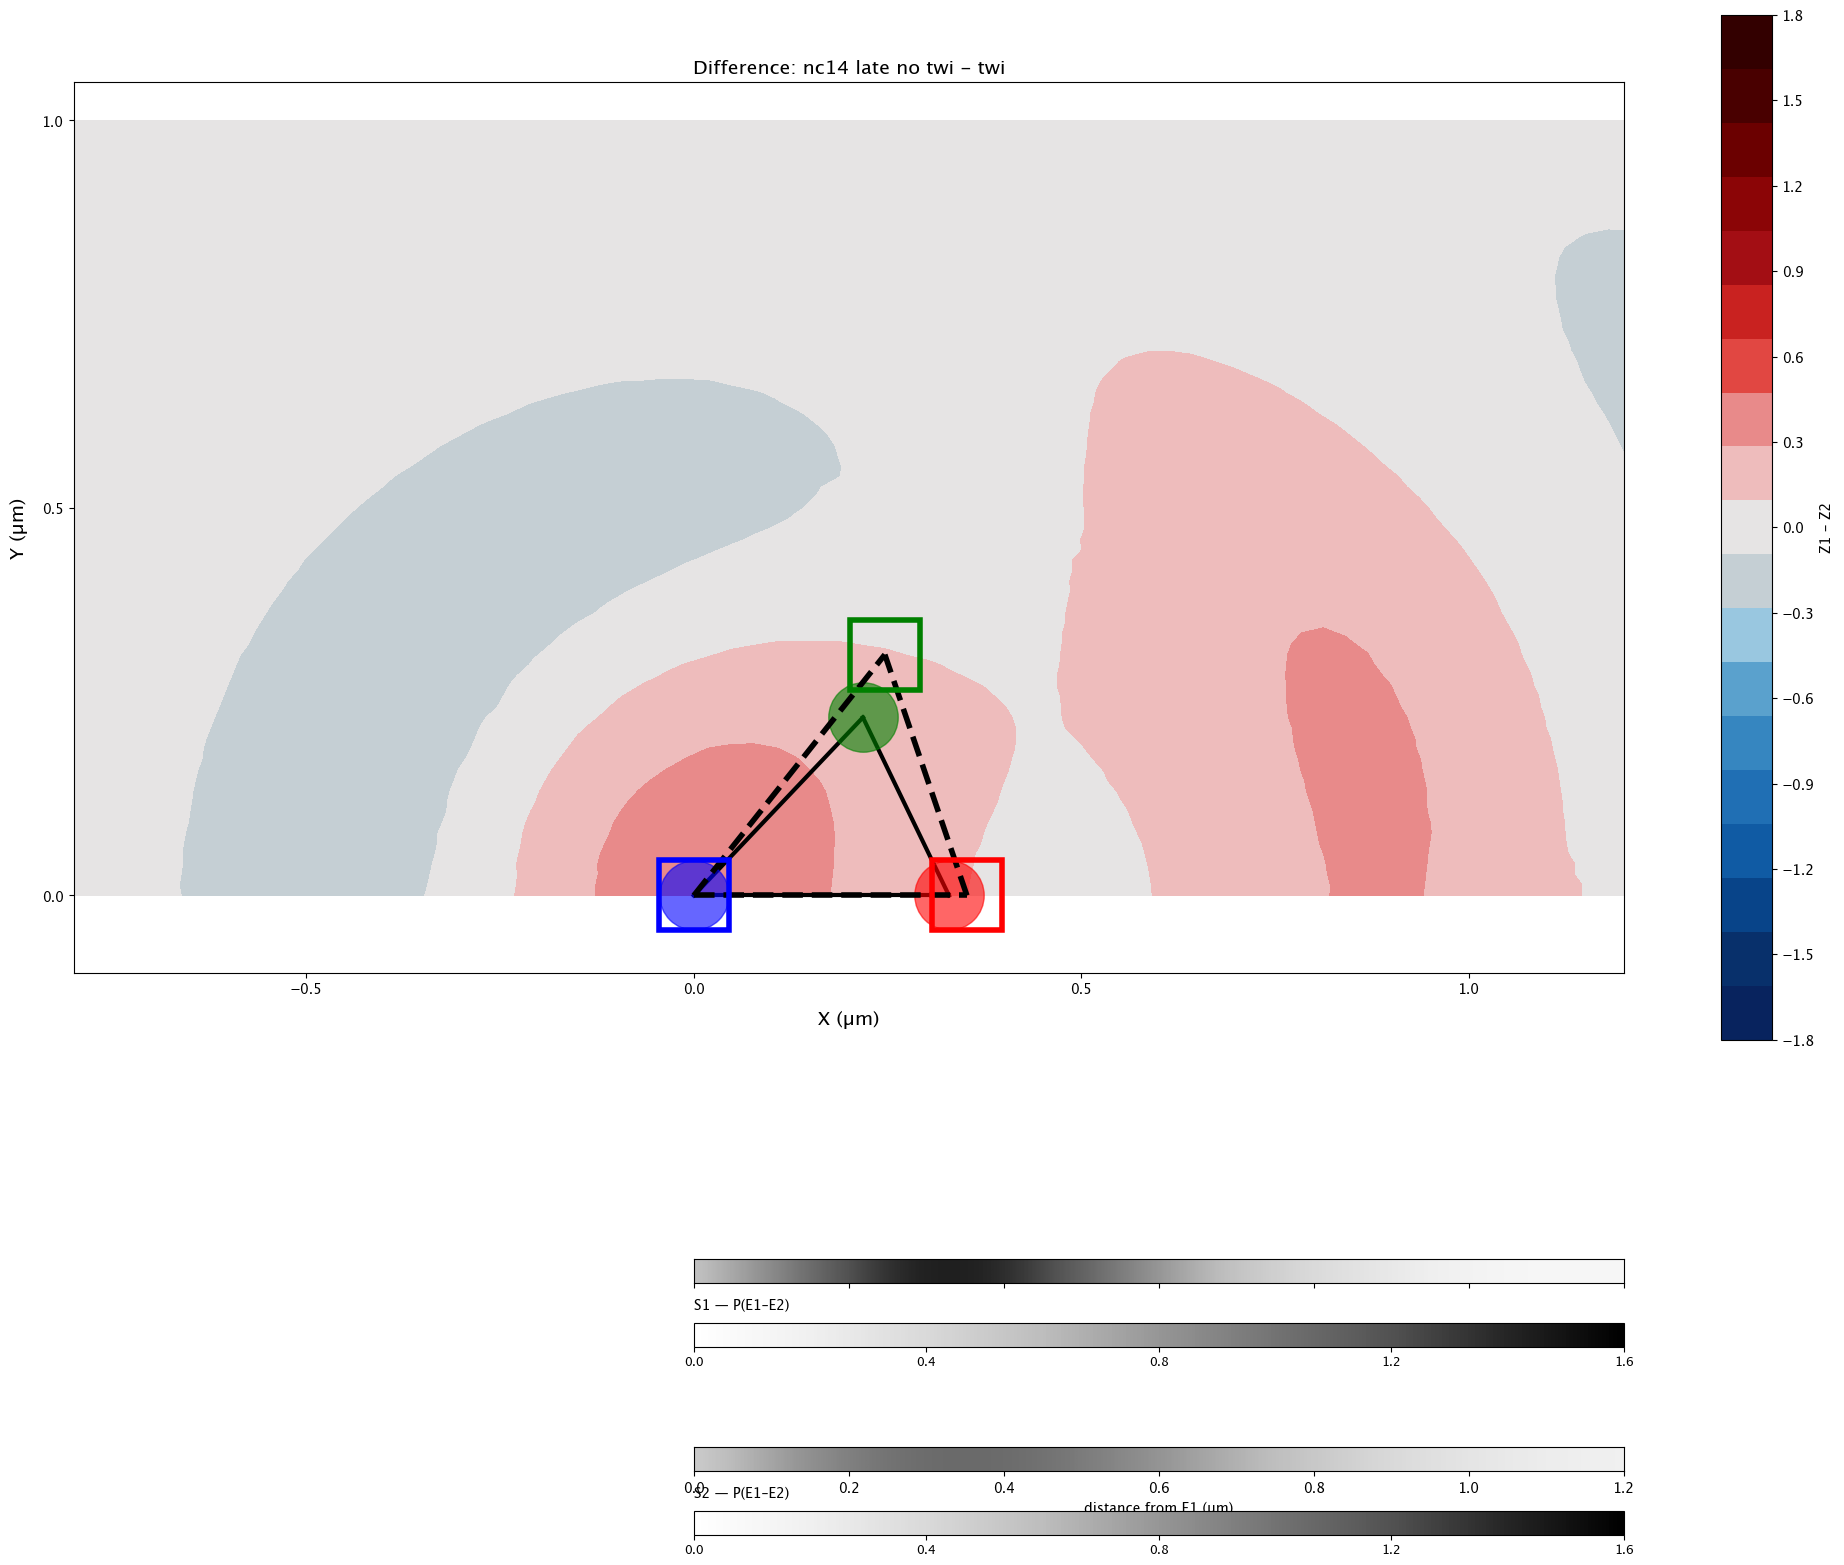

In [25]:
plot_difference_contour_with_e1e2_pdf(Z_weighted_nc14_late_no_twist, X_grid_nc14_late_no_twist,Y_grid_nc14_late_no_twist,
                        Z_weighted_nc14_late_twist, X_grid_nc14_late_twist,Y_grid_nc14_late_twist,
                        E1_nc14_late_no_twist, E2_nc14_late_no_twist, PPE_nc14_late_no_twist,
                        E1_nc14_late_twist, E2_nc14_late_twist, PPE_nc14_late_twist,
                        kde_results_e1_e2['no twi']['x'], kde_results_e1_e2['no twi']['y'],
                        kde_results_e1_e2['twi']['x'], kde_results_e1_e2['twi']['y'],                
                        title="Difference: nc14 late no twi - twi")